# NM Sanity Check v3 — Sudogwon 2019-2020 (HIRA)

19-dim vector (seasonality fixed), cosine sf, beta from R0 sweep.

| param | value | rationale |
|---|---|---|
| beta (all ch) | 0.06 | R0_peak ~ 1.8 (safety margin, sweep result) |
| phi | 1.0 (all) | reference |
| gamma_report | 0.2 | domain estimate |
| seasonality | cosine, amp=0.7, peak=105 | fixed |
| min_rate | 0.01 | HIRA-D |
| initial_immunity | 0.3 | prior season |


In [1]:
# Cell 1 — Imports + setup
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

from kt_data import HIRA_AGE_GROUPS, SUDOGWON_SIDO_CODES

from kt_epimodel_hira.calibration.hira_target import (
    HIRA_GROUP_TO_NIMS_WEIGHTED,
    load_hira_target_by_age,
    simulation_to_hira_by_age,
    poisson_log_likelihood,
)
from kt_epimodel_hira.calibration.simple_model import (
    build_aggregated_inputs,
    estimate_initial_infected_from_hira,
    simulate_aggregated,
)
from kt_epimodel_hira.calibration.loss import make_loss_function_by_age
from kt_epimodel_hira.calibration.param_vector import (
    get_bounds_vector, get_param_names, initial_guess, vector_to_params,
    params_to_vector, ParameterBounds,
)
from kt_epimodel_hira.model.parameters import (
    CalibrationParameters, DiseaseParameters, ModelParameters,
)

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150,
                     "axes.unicode_minus": False,
                     "font.family": "DejaVu Sans"})

OUTDIR = Path("../outputs/calibration")
OUTDIR.mkdir(parents=True, exist_ok=True)
JSON_PATH = OUTDIR / "sanity_nm_2019-2020_HIRA_v3.json"
FIT_PNG   = OUTDIR / "sanity_nm_2019-2020_HIRA_v3.png"
DIAG_PNG  = OUTDIR / "sanity_nm_2019-2020_HIRA_v3_diagnostics.png"
NLL_PNG   = OUTDIR / "sanity_nm_2019-2020_HIRA_v3_nll_decomp.png"

SEASON = "2019-2020"
MAX_ITER = 100
GAMMA_ASSUMED = 0.2
SEED_E_FACTOR = 0.5
INITIAL_IMMUNITY = 0.3
FIRST_PEAK_END_WEEK = 26
MIN_RATE = 0.01
BETA_INIT = 0.06  # R0_peak ~ 1.8

dis = DiseaseParameters()  # cosine, amp=0.7, peak=105, base=1.0
print(f"sanity NM v3 for {SEASON}")
print(f"  19-dim vector, beta_init={BETA_INIT}")
print(f"  seasonality: {dis.seasonality_mode}, amp={dis.seasonality_amp}, "
      f"base={dis.seasonality_base}, peak={dis.seasonality_peak_day}")
print(f"  sf(peak): {dis.seasonal_factor(dis.seasonality_peak_day):.3f}")
print(f"  min_rate={MIN_RATE}")


sanity NM v3 for 2019-2020
  19-dim vector, beta_init=0.06
  seasonality: cosine, amp=0.7, base=1.0, peak=105.0
  sf(peak): 1.700
  min_rate=0.01


In [2]:
# Cell 2 — Load target + inputs + seed
target_by_age = load_hira_target_by_age(
    SEASON, sido_codes=list(SUDOGWON_SIDO_CODES),
    first_peak_only=True, first_peak_end_week=FIRST_PEAK_END_WEEK,
)
print(f"n_weeks: {target_by_age['n_weeks']}, fit weeks < {FIRST_PEAK_END_WEEK}")
print("\nObserved peaks:")
for ag in HIRA_AGE_GROUPS:
    pk = float(target_by_age["hira_counts"][ag].max())
    pw = int(np.argmax(target_by_age["hira_counts"][ag]))
    print(f"  {ag:>6}: peak={pk:>7,.0f} @ W{pw}")

inputs = build_aggregated_inputs()
pop_15 = inputs["pop_15"].flatten()

seed_by_age = estimate_initial_infected_from_hira(
    SEASON, pop_15, sido_codes=list(SUDOGWON_SIDO_CODES),
    gamma_report_assumed=GAMMA_ASSUMED,
)
print(f"\nSeed total: {seed_by_age.sum():.1f}")


n_weeks: 52, fit weeks < 26

Observed peaks:
     0-5: peak= 15,926 @ W16
    6-11: peak= 32,220 @ W16
   12-17: peak= 18,538 @ W16
   18-44: peak= 47,849 @ W17
   45-64: peak= 25,418 @ W17
     65+: peak=  6,820 @ W18

Seed total: 2023.3


In [3]:
# Cell 3 — R0 check + initial vector
cal_init = CalibrationParameters(
    beta_h=BETA_INIT, beta_w=BETA_INIT, beta_s=BETA_INIT, beta_o=BETA_INIT,
    phi=np.ones(15), gamma_report=0.2,
)
init_vec = params_to_vector(cal_init)
names = get_param_names()

print(f"Initial vector (19-dim):")
for n, v in zip(names, init_vec):
    print(f"  {n:>18}: {v:.4f}")

# R0 via NGM
def compute_R0_ngm(cal, disease, inputs_dict, initial_immunity=0.3):
    pop = inputs_dict["pop_15"].flatten()
    N_safe = np.maximum(pop, 1e-10)
    matrices = inputs_dict["matrices"]
    rho = inputs_dict["rho"].flatten()
    gamma = disease.gamma
    sf = disease.seasonal_factor(disease.seasonality_peak_day)
    s_frac = 1.0 - initial_immunity

    C_eff = np.zeros((15, 15))
    C_eff += cal.beta_h * matrices["C_home"]
    C_eff[:4, :4] += cal.beta_s * matrices["C_school"][:4, :4]
    rho_ok = (rho > 0).astype(float)
    for a in range(4, 14):
        C_eff[a, :] += cal.beta_w * matrices["C_work"][a, :] * rho[a] * rho_ok
    C_eff += cal.beta_o * matrices["C_other"]

    K = (s_frac * sf / gamma) * np.diag(pop) @ np.diag(cal.phi) @ C_eff @ np.diag(1.0 / N_safe)
    eigvals = np.linalg.eigvals(K)
    R0 = float(np.max(np.real(eigvals)))
    return R0, sf

R0_init, sf_peak = compute_R0_ngm(cal_init, dis, inputs, INITIAL_IMMUNITY)
print(f"\nR0 = {R0_init:.3f} (sf_peak={sf_peak:.3f})")
if R0_init < 1.0:
    print("WARNING: R0 < 1")
elif R0_init > 2.5:
    print("WARNING: R0 > 2.5")
else:
    print("OK: R0 in [1.0, 2.5]")


Initial vector (19-dim):
              beta_h: 0.0600
              beta_w: 0.0600
              beta_s: 0.0600
              beta_o: 0.0600
               phi_0: 1.0000
               phi_1: 1.0000
               phi_2: 1.0000
               phi_3: 1.0000
               phi_4: 1.0000
               phi_6: 1.0000
               phi_7: 1.0000
               phi_8: 1.0000
               phi_9: 1.0000
              phi_10: 1.0000
              phi_11: 1.0000
              phi_12: 1.0000
              phi_13: 1.0000
              phi_14: 1.0000
        gamma_report: 0.2000

R0 = 1.793 (sf_peak=1.700)
OK: R0 in [1.0, 2.5]


In [4]:
# Cell 4 — Forward sim + initial NLL
def predict_from_vec(vec):
    cal = vector_to_params(vec)
    params = ModelParameters().with_calibration(cal)
    res = simulate_aggregated(
        params, inputs, seed_total=float(seed_by_age.sum()),
        seed_by_age=seed_by_age, seed_e_factor=SEED_E_FACTOR,
        initial_immunity=INITIAL_IMMUNITY,
        initial_vaccinated_fraction=0.0, t_span=(0.0, 364.0),
    )
    if not res.success:
        raise RuntimeError(f"solver failed: {res.message}")
    daily_inc = res.daily_new_infection_by_age()
    pred_by_age = simulation_to_hira_by_age(
        daily_inc, cal.gamma_report, n_weeks=target_by_age["n_weeks"],
    )
    return pred_by_age, res

pred_init, _ = predict_from_vec(init_vec)

print("Initial prediction peaks:")
for ag in HIRA_AGE_GROUPS:
    p = pred_init[ag]
    obs_pk = float(target_by_age["hira_counts"][ag].max())
    pred_pk = float(p.max())
    pw = int(np.argmax(p))
    ratio = pred_pk / max(obs_pk, 1)
    print(f"  {ag:>6}: pred={pred_pk:>10,.1f} @ W{pw}  obs={obs_pk:>10,.0f}  ratio={ratio:.2f}")

outbreak = max(pred_init[ag].max() for ag in HIRA_AGE_GROUPS) > 100
print(f"\nOutbreak: {'YES' if outbreak else 'NO'}")

total_nll_init = sum(
    poisson_log_likelihood(
        target_by_age["hira_counts"][ag], pred_init[ag],
        is_valid=target_by_age["is_valid"][ag],
        weights=target_by_age["weights"][ag], min_rate=MIN_RATE,
    ) for ag in HIRA_AGE_GROUPS
)
print(f"Initial NLL: {total_nll_init:,.2f}")


Initial prediction peaks:
     0-5: pred=   2,496.2 @ W18  obs=    15,926  ratio=0.16
    6-11: pred=  10,685.7 @ W17  obs=    32,220  ratio=0.33
   12-17: pred=  13,360.8 @ W17  obs=    18,538  ratio=0.72
   18-44: pred=  57,366.8 @ W18  obs=    47,849  ratio=1.20
   45-64: pred=  50,326.5 @ W18  obs=    25,418  ratio=1.98
     65+: pred=  14,080.3 @ W18  obs=     6,820  ratio=2.06

Outbreak: YES
Initial NLL: -6,532,167.01


In [5]:
# Cell 5 — NM 100 iter
target_loss_fn = make_loss_function_by_age(
    target_by_age, inputs, ModelParameters(),
    seed_total=float(seed_by_age.sum()),
    seed_by_age=seed_by_age, seed_e_factor=SEED_E_FACTOR,
    initial_immunity=INITIAL_IMMUNITY,
    initial_vaccinated_fraction=0.0, t_span=(0.0, 364.0), verbose=False,
)

nll_history = []
vec_history = []
def loss_with_history(vec):
    v = float(target_loss_fn(vec))
    nll_history.append(v)
    vec_history.append(np.asarray(vec, dtype=np.float64).copy())
    return v

bounds = get_bounds_vector()
print(f"Running NM, maxiter={MAX_ITER} ...")
t0 = time.perf_counter()
sol = minimize(
    loss_with_history, init_vec,
    method="Nelder-Mead", bounds=bounds,
    options={"maxiter": MAX_ITER, "xatol": 1e-2, "fatol": 1e-1,
             "disp": True, "adaptive": True},
)
elapsed = time.perf_counter() - t0
print(f"\nevals={sol.nfev}  elapsed={elapsed:.1f}s")
print(f"NLL: {nll_history[0]:,.2f} -> {sol.fun:,.2f}  "
      f"(delta: {nll_history[0] - sol.fun:+,.2f})")
print(f"Termination: {sol.message}")


Running NM, maxiter=100 ...



evals=161  elapsed=235.7s
NLL: -6,532,167.01 -> -6,665,084.11  (delta: +132,917.10)
Termination: Maximum number of iterations has been exceeded.


/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_56644/2513303972.py:21: RuntimeWarning: Maximum number of iterations has been exceeded.
  sol = minimize(


saved ../outputs/calibration/sanity_nm_2019-2020_HIRA_v3.png


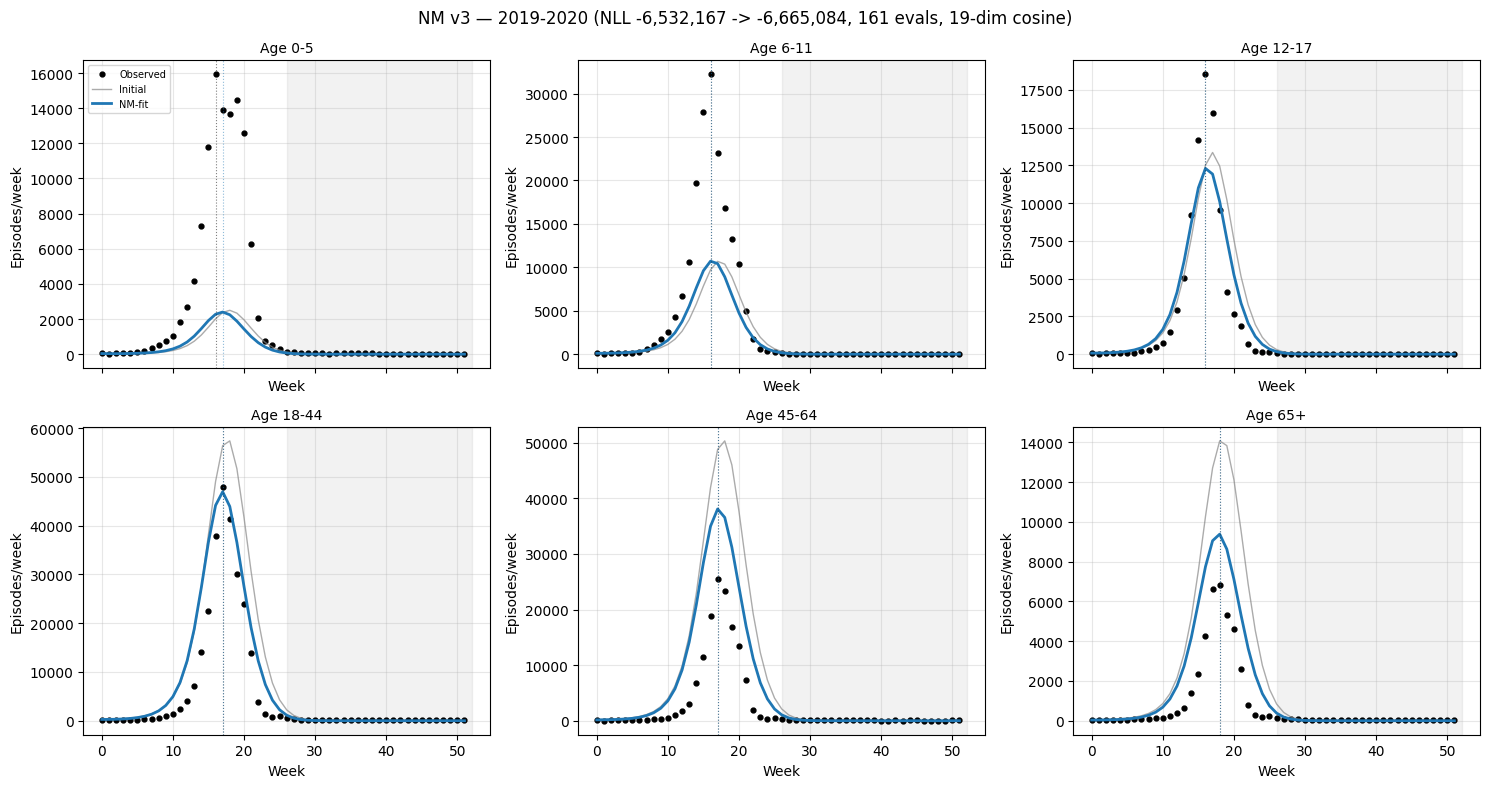

In [6]:
# Cell 6 — Fit plot
pred_final, _ = predict_from_vec(sol.x)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, ag in zip(axes.flat, HIRA_AGE_GROUPS):
    obs = target_by_age["hira_counts"][ag]
    pi = pred_init[ag]
    pf = pred_final[ag]
    weeks_obs = target_by_age["week_in_season"]
    ax.plot(weeks_obs, obs, "o", color="black", ms=3.5, label="Observed")
    ax.plot(np.arange(len(pi)), pi, color="#888888", lw=1.0, alpha=0.7, label="Initial")
    ax.plot(np.arange(len(pf)), pf, color="#1f77b4", lw=2.0, label="NM-fit")
    ax.axvspan(FIRST_PEAK_END_WEEK, len(pf), alpha=0.10, color="gray")
    if obs.max() > 0:
        ax.axvline(int(np.argmax(obs)), color="black", ls=":", lw=0.8, alpha=0.5)
    if pf.max() > 0:
        ax.axvline(int(np.argmax(pf)), color="#1f77b4", ls=":", lw=0.8, alpha=0.5)
    ax.set_title(f"Age {ag}", fontsize=10)
    ax.set_xlabel("Week"); ax.set_ylabel("Episodes/week")
    ax.grid(alpha=0.3)
    if ax is axes.flat[0]:
        ax.legend(fontsize=7)
fig.suptitle(f"NM v3 — {SEASON} (NLL {nll_history[0]:,.0f} -> {sol.fun:,.0f}, "
             f"{sol.nfev} evals, 19-dim cosine)", fontsize=12)
fig.tight_layout()
fig.savefig(FIT_PNG, dpi=150, bbox_inches="tight")
print(f"saved {FIT_PNG}")
plt.show()


In [7]:
# Cell 7 — Diagnostics
final_vec = sol.x
bounds_arr = np.array(bounds)
lo, hi = bounds_arr[:, 0], bounds_arr[:, 1]
span = hi - lo
TOL = 0.02

print("Bound hits (within 2%):")
hit_lo, hit_hi = [], []
for i, n in enumerate(names):
    if (final_vec[i] - lo[i]) / span[i] < TOL:
        hit_lo.append((n, final_vec[i], lo[i]))
    if (hi[i] - final_vec[i]) / span[i] < TOL:
        hit_hi.append((n, final_vec[i], hi[i]))
if not hit_lo and not hit_hi:
    print("  (none)")
for n, v, b in hit_lo:
    print(f"  LOWER  {n:>18}: {v:.4f}  (bound {b:.4f})")
for n, v, b in hit_hi:
    print(f"  UPPER  {n:>18}: {v:.4f}  (bound {b:.4f})")

print(f"\ngamma_report: {final_vec[18]:.4f}")

# Phi
phi_vec = np.ones(15)
idx = 4
for a in range(15):
    if a == 5: continue
    phi_vec[a] = final_vec[idx]; idx += 1
phi_c = phi_vec[:4].mean()
phi_a = phi_vec[4:13].mean()
phi_e = phi_vec[13:].mean()
print(f"\nPhi: children={phi_c:.3f}  adult={phi_a:.3f}  elderly={phi_e:.3f}")

# min_rate floor
n_floor = sum(int(np.sum(pred_final[ag][target_by_age["weights"][ag] > 0] < MIN_RATE))
              for ag in HIRA_AGE_GROUPS)
n_total = sum(int((target_by_age["weights"][ag] > 0).sum()) for ag in HIRA_AGE_GROUPS)
print(f"\nmin_rate floor: {n_floor}/{n_total} = {n_floor/max(n_total,1)*100:.1f}%")

# Peak alignment + age bias
print(f"\nPeak alignment + age bias:")
peak_align = []
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]
    pf = pred_final[ag]
    if obs.max() == 0 or pf.max() == 0: continue
    pw_o = int(np.argmax(obs))
    pw_p = int(np.argmax(pf))
    d = pw_p - pw_o
    r = pf.max() / obs.max()
    peak_align.append((ag, pw_o, pw_p, d))
    flag = "overshoot" if r > 1.5 else ("undershoot" if r < 0.66 else "ok")
    print(f"  {ag:>6}: obs W{pw_o:>2}  pred W{pw_p:>2}  delta={d:+d}  "
          f"ratio={r:.2f} {flag}")

# R0 final
cal_final = vector_to_params(sol.x)
R0_final, sf_f = compute_R0_ngm(cal_final, dis, inputs, INITIAL_IMMUNITY)
print(f"\nR0: {R0_init:.3f} -> {R0_final:.3f}")

# Beta movement
print(f"\nBeta trajectory:")
beta_names = ["beta_h", "beta_w", "beta_s", "beta_o"]
for i, bn in enumerate(beta_names):
    pct = (final_vec[i] - init_vec[i]) / max(abs(init_vec[i]), 1e-10) * 100
    print(f"  {bn}: {init_vec[i]:.4f} -> {final_vec[i]:.4f}  ({pct:+.1f}%)")
beta_moved = any(
    abs(final_vec[i] - init_vec[i]) / max(abs(init_vec[i]), 1e-10) > 0.05
    for i in range(4)
)
print(f"  Moved >5%: {beta_moved}")


Bound hits (within 2%):
  LOWER              beta_h: 0.0547  (bound 0.0010)
  LOWER              beta_w: 0.0577  (bound 0.0010)
  LOWER              beta_s: 0.0647  (bound 0.0010)
  LOWER              beta_o: 0.0495  (bound 0.0010)

gamma_report: 0.1754

Phi: children=1.051  adult=1.012  elderly=1.007

min_rate floor: 0/156 = 0.0%

Peak alignment + age bias:
     0-5: obs W16  pred W17  delta=+1  ratio=0.15 undershoot
    6-11: obs W16  pred W16  delta=+0  ratio=0.33 undershoot
   12-17: obs W16  pred W16  delta=+0  ratio=0.66 ok
   18-44: obs W17  pred W17  delta=+0  ratio=0.98 ok
   45-64: obs W17  pred W17  delta=+0  ratio=1.50 ok
     65+: obs W18  pred W18  delta=+0  ratio=1.38 ok

R0: 1.793 -> 1.851

Beta trajectory:
  beta_h: 0.0600 -> 0.0547  (-8.8%)
  beta_w: 0.0600 -> 0.0577  (-3.8%)
  beta_s: 0.0600 -> 0.0647  (+7.8%)
  beta_o: 0.0600 -> 0.0495  (-17.5%)
  Moved >5%: True


saved ../outputs/calibration/sanity_nm_2019-2020_HIRA_v3_nll_decomp.png

NLL by age:
     0-5:  -798,876.99  (-12.0%)
    6-11: -1,508,494.69  (-22.6%)
   12-17:  -712,366.59  (-10.7%)
   18-44: -2,306,495.68  (-34.6%)
   45-64: -1,082,499.72  (-16.2%)
     65+:  -256,350.44  (-3.8%)


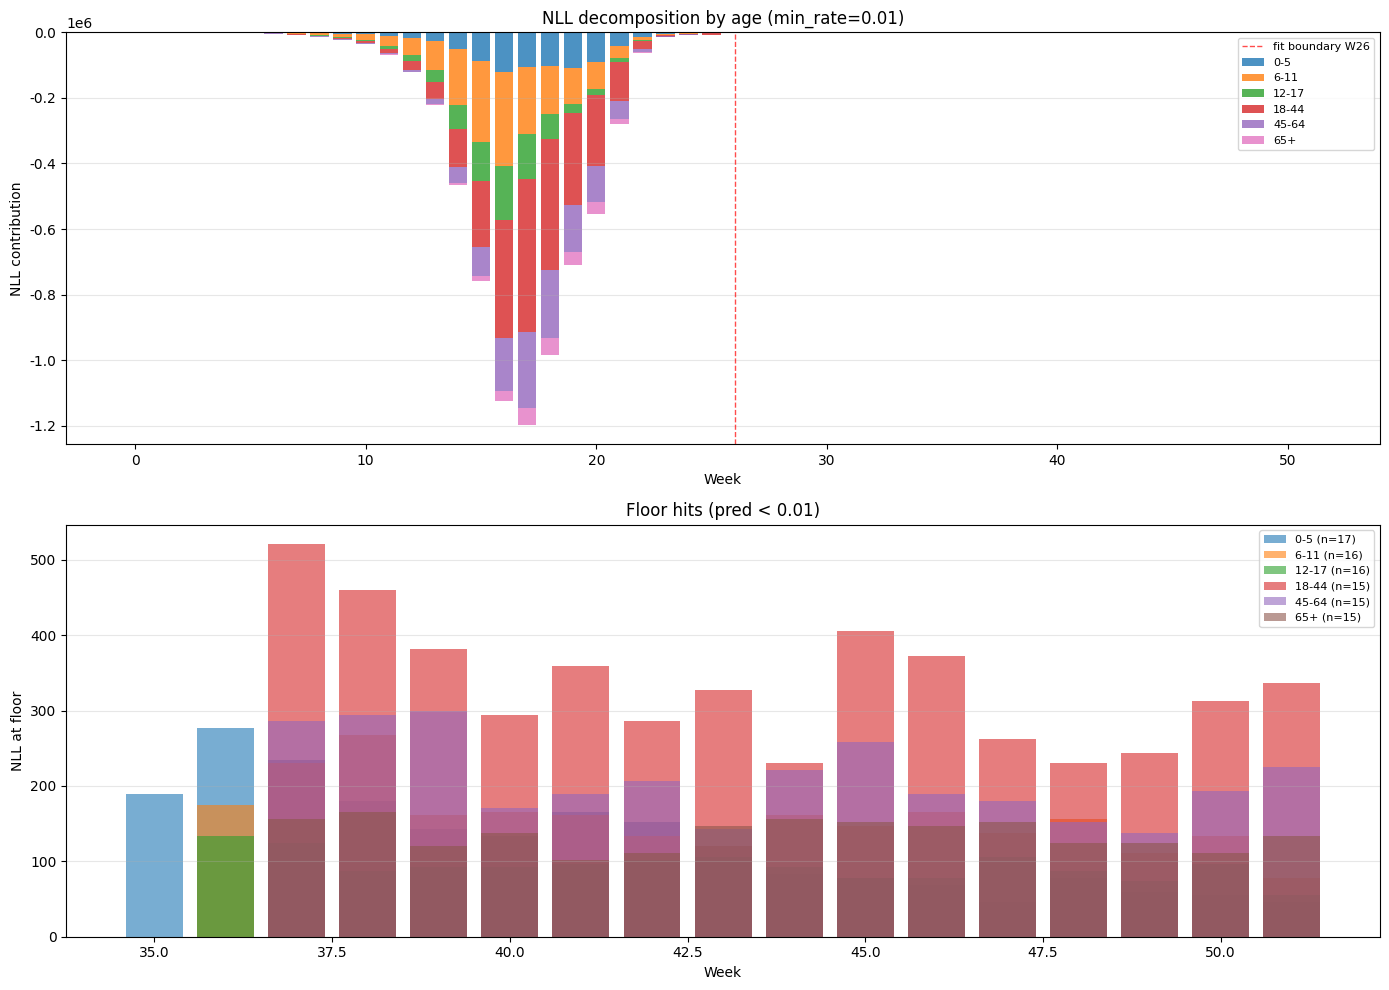

In [8]:
# Cell 8 — NLL decomposition
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

nll_per_week_age = {}
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]
    pf = pred_final[ag]
    w = target_by_age["weights"][ag]
    n_wk = min(len(obs), len(pf))
    pred_c = np.maximum(pf[:n_wk], MIN_RATE)
    nll_per_week_age[ag] = w[:n_wk] * (pred_c - obs[:n_wk] * np.log(pred_c))

weeks_x = np.arange(max(len(v) for v in nll_per_week_age.values()))
ax = axes[0]
bottom = np.zeros(len(weeks_x))
colors = plt.cm.tab10(np.linspace(0, 0.6, len(HIRA_AGE_GROUPS)))
for (ag, nll_w), c in zip(nll_per_week_age.items(), colors):
    padded = np.zeros(len(weeks_x))
    padded[:len(nll_w)] = nll_w
    ax.bar(weeks_x, padded, bottom=bottom, width=0.8, label=ag, color=c, alpha=0.8)
    bottom += padded
ax.axvline(FIRST_PEAK_END_WEEK, color="red", ls="--", lw=1, alpha=0.7,
           label=f"fit boundary W{FIRST_PEAK_END_WEEK}")
ax.set_xlabel("Week"); ax.set_ylabel("NLL contribution")
ax.set_title(f"NLL decomposition by age (min_rate={MIN_RATE})")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

# Spurious floor check
ax = axes[1]
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]
    pf = pred_final[ag]
    w = target_by_age["weights"][ag]
    n_wk = min(len(obs), len(pf))
    floor_mask = pf[:n_wk] < MIN_RATE
    fc = int(floor_mask.sum())
    if fc > 0:
        obs_f = obs[:n_wk][floor_mask]
        spurious = MIN_RATE - obs_f * np.log(MIN_RATE)
        ax.bar(np.where(floor_mask)[0], spurious, width=0.8, alpha=0.6,
               label=f"{ag} (n={fc})")
ax.set_xlabel("Week"); ax.set_ylabel("NLL at floor")
ax.set_title(f"Floor hits (pred < {MIN_RATE})")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(NLL_PNG, dpi=150, bbox_inches="tight")
print(f"saved {NLL_PNG}")

# NLL summary
total_nll = sum(nll_per_week_age[ag].sum() for ag in HIRA_AGE_GROUPS)
print(f"\nNLL by age:")
for ag in HIRA_AGE_GROUPS:
    v = float(nll_per_week_age[ag].sum())
    print(f"  {ag:>6}: {v:>12,.2f}  ({v/max(abs(total_nll),1)*100:.1f}%)")
plt.show()


saved ../outputs/calibration/sanity_nm_2019-2020_HIRA_v3_diagnostics.png


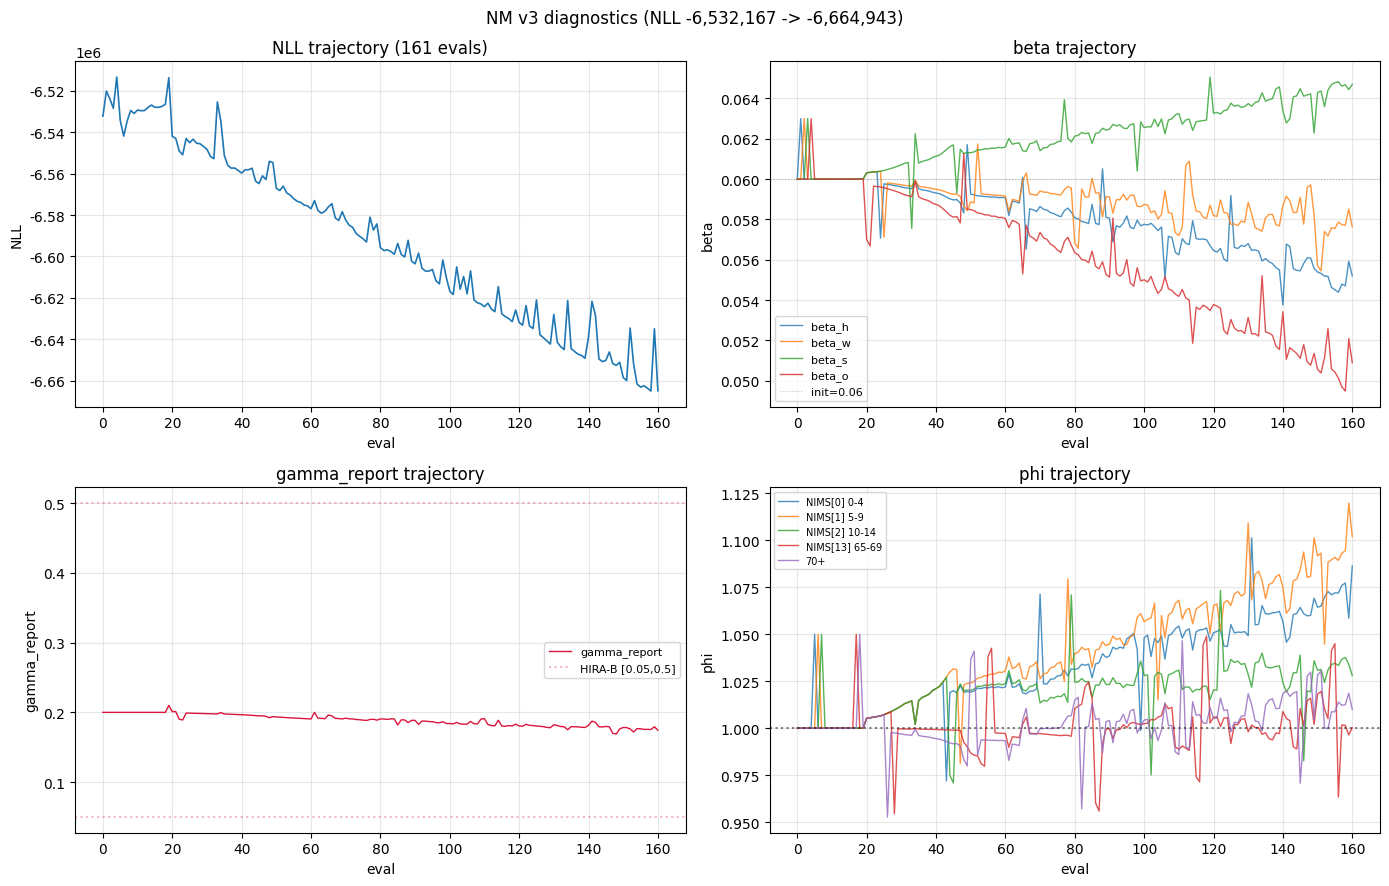

In [9]:
# Cell 9 — Trajectory diagnostics
nll_arr = np.asarray(nll_history)
vec_arr = np.asarray(vec_history)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.plot(nll_arr, lw=1.2, color="#1f77b4")
ax.set_xlabel("eval"); ax.set_ylabel("NLL")
ax.set_title(f"NLL trajectory ({len(nll_arr)} evals)")
ax.grid(alpha=0.3)
if nll_arr.max() / max(nll_arr.min(), 1e-9) > 50:
    ax.set_yscale("log")

ax = axes[0, 1]
for i, label in enumerate(["beta_h", "beta_w", "beta_s", "beta_o"]):
    ax.plot(vec_arr[:, i], lw=1.0, label=label, alpha=0.8)
ax.axhline(BETA_INIT, color="gray", ls=":", lw=0.8, alpha=0.5, label=f"init={BETA_INIT}")
ax.set_xlabel("eval"); ax.set_ylabel("beta")
ax.set_title("beta trajectory"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(vec_arr[:, 18], lw=1.0, color="crimson", label="gamma_report")
ax.axhline(0.05, color="crimson", ls=":", alpha=0.3)
ax.axhline(0.5, color="crimson", ls=":", alpha=0.3, label="HIRA-B [0.05,0.5]")
ax.set_xlabel("eval"); ax.set_ylabel("gamma_report")
ax.set_title("gamma_report trajectory"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
phi_idx = {}; idx = 4
for a in range(15):
    if a == 5: continue
    phi_idx[a] = idx; idx += 1
for a in [0, 1, 2, 13, 14]:
    label = "70+" if a == 14 else f"NIMS[{a}] {a*5}-{a*5+4}"
    ax.plot(vec_arr[:, phi_idx[a]], lw=1.0, label=label, alpha=0.8)
ax.axhline(1.0, color="black", ls=":", alpha=0.5)
ax.set_xlabel("eval"); ax.set_ylabel("phi")
ax.set_title("phi trajectory"); ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig.suptitle(f"NM v3 diagnostics (NLL {nll_arr[0]:,.0f} -> {nll_arr[-1]:,.0f})", fontsize=12)
fig.tight_layout()
fig.savefig(DIAG_PNG, dpi=150, bbox_inches="tight")
print(f"saved {DIAG_PNG}")
plt.show()


In [10]:
# Cell 10 — Save JSON
import json

result = {
    "season": SEASON, "tag": "sanity_nm_v3", "method": "Nelder-Mead",
    "max_iter": MAX_ITER, "n_evaluations": int(sol.nfev),
    "success": bool(sol.success), "message": str(sol.message),
    "elapsed_seconds": float(elapsed),
    "nll_initial": float(nll_history[0]), "nll_final": float(sol.fun),
    "nll_improvement": float(nll_history[0] - sol.fun),
    "vector_dim": len(init_vec),
    "vector_initial": [float(v) for v in init_vec],
    "vector_final": [float(v) for v in sol.x],
    "param_names": names,
    "bounds": [(float(a), float(b)) for a, b in bounds],
    "bound_hits_lower": [n for n, _, _ in hit_lo],
    "bound_hits_upper": [n for n, _, _ in hit_hi],
    "seasonality": {"mode": "cosine", "amp": 0.7, "base": 1.0, "peak_day": 105.0},
    "gamma_report_assumed": GAMMA_ASSUMED,
    "seed_e_factor": SEED_E_FACTOR,
    "initial_immunity": INITIAL_IMMUNITY,
    "first_peak_end_week": FIRST_PEAK_END_WEEK,
    "seed_total": float(seed_by_age.sum()),
    "min_rate": MIN_RATE,
    "min_rate_floor_hits": n_floor,
    "R0_initial": float(R0_init),
    "R0_final": float(R0_final),
    "phi_blocks": {"children": float(phi_c), "adult": float(phi_a), "elderly": float(phi_e)},
    "peak_alignment": [
        {"age": ag, "obs_w": int(wo), "pred_w": int(wp), "delta": int(d)}
        for ag, wo, wp, d in peak_align
    ],
    "age_bias": {
        ag: float(pred_final[ag].max() / max(target_by_age["hira_counts"][ag].max(), 1))
        for ag in HIRA_AGE_GROUPS
    },
    "beta_pct_change": {
        beta_names[i]: float((sol.x[i] - init_vec[i]) / max(abs(init_vec[i]), 1e-10) * 100)
        for i in range(4)
    },
}

with open(JSON_PATH, "w") as f:
    json.dump(result, f, indent=2)
print(f"saved {JSON_PATH}")
print(f"\n=== Summary ===")
print(f"NLL: {result['nll_initial']:,.2f} -> {result['nll_final']:,.2f}")
print(f"R0: {result['R0_initial']:.3f} -> {result['R0_final']:.3f}")
print(f"Wall: {result['elapsed_seconds']:.1f}s, {sol.nfev} evals")
print(f"Bounds: lo={result['bound_hits_lower']} hi={result['bound_hits_upper']}")
print(f"Floor: {n_floor}/{n_total}")
print(f"Beta moved: {beta_moved}")


saved ../outputs/calibration/sanity_nm_2019-2020_HIRA_v3.json

=== Summary ===
NLL: -6,532,167.01 -> -6,665,084.11
R0: 1.793 -> 1.851
Wall: 235.7s, 161 evals
Bounds: lo=['beta_h', 'beta_w', 'beta_s', 'beta_o'] hi=[]
Floor: 0/156
Beta moved: True
